# Data Binning intro

**Data Binning** is usually about transforming a variable from many numbers to a few values, intervals, labels, or *bins*.<br>
**Administrative Data Binning** is the most common Data Binning method and means that some criterion is used to define the borders between different bins.
- This could be school ages, e.g. that 11-13 (*values*) goes to mid school (*bin*, *category*, and/or *label*) according to some authorities' definition, or
- Simply be determined arbitrarily by the user or Data Scientist.

**Algorithmic Data Binning** is very common in Data Science and Machine Learning and can be used for everything from Data-dependent cluster analysis creation, creating rules for clusters or groups which can be used to classify new data points into.

In [1]:
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Practical examples

In [2]:
geyser = sns.load_dataset("geyser")
geyser

,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long
...,...,...,...
267,4.117,81,long
268,2.150,46,short
269,4.417,90,long
270,1.817,46,short


There are three *features* or *variables*:
- **duration** of geyser bursts,
- **waiting** time between the bursts,
- a type of predefined administrative *binning* or *categorization* - **kind**

Use a simple Seaborn histogram to further study the *feature* or *variabe* distribution

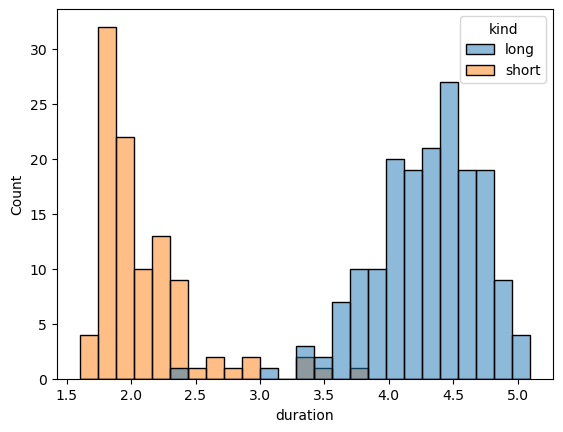

In [3]:
sns.histplot(data=geyser, x="duration", bins=25, hue="kind")
plt.show()

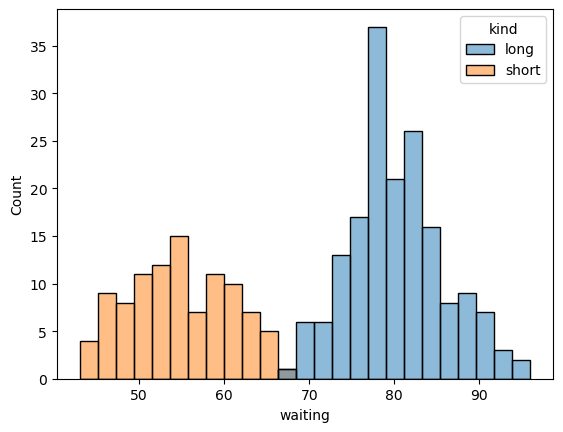

In [4]:
sns.histplot(data=geyser, x="waiting", bins=25, hue="kind")
plt.show()

## Pandas' quantile cut Binning algorithm 

In [5]:
geyser["qcutDur2"] = pd.qcut(geyser.duration, q=2, labels=["short", "long"])
geyser["qcutDur3"] = pd.qcut(geyser.duration, q=3, labels=["short", "medium", "long"])
geyser

,duration,waiting,kind,qcutDur2,qcutDur3
0,3.600,79,long,short,medium
1,1.800,54,short,short,short
2,3.333,74,long,short,medium
3,2.283,62,short,short,short
4,4.533,85,long,long,long
...,...,...,...,...,...
267,4.117,81,long,long,medium
268,2.150,46,short,short,short
269,4.417,90,long,long,long
270,1.817,46,short,short,short


Plot the new binnings with matplotlib and seaborn

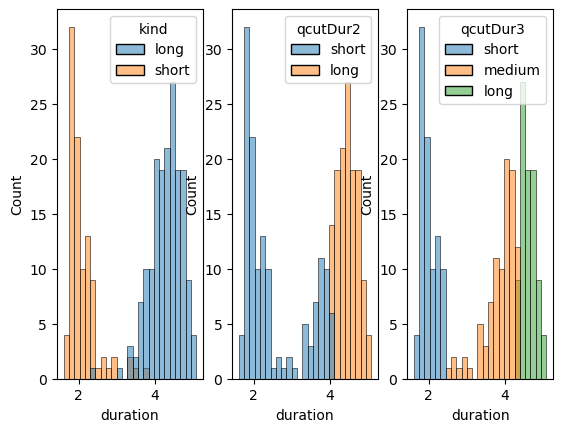

In [6]:
fig, ((h_dur, qc_dur2, qc_dur3)) = plt.subplots(1, 3)
sns.histplot(data=geyser, x="duration", bins=25, hue="kind", ax=h_dur)
sns.histplot(data=geyser, x="duration", bins=25, hue="qcutDur2", ax=qc_dur2)
sns.histplot(data=geyser, x="duration", bins=25, hue="qcutDur3", ax= qc_dur3)
plt.show()

## Pandas' `cut()` function

In [7]:
geyser["cutDur2"] = pd.cut(geyser.duration, bins=2, labels=["short", "long"])
geyser["cutDur3"] = pd.cut(geyser.duration, bins=3, labels=["short", "medium", "long"])
geyser

,duration,waiting,kind,qcutDur2,qcutDur3,cutDur2,cutDur3
0,3.600,79,long,short,medium,long,medium
1,1.800,54,short,short,short,short,short
2,3.333,74,long,short,medium,short,medium
3,2.283,62,short,short,short,short,short
4,4.533,85,long,long,long,long,long
...,...,...,...,...,...,...,...
267,4.117,81,long,long,medium,long,long
268,2.150,46,short,short,short,short,short
269,4.417,90,long,long,long,long,long
270,1.817,46,short,short,short,short,short


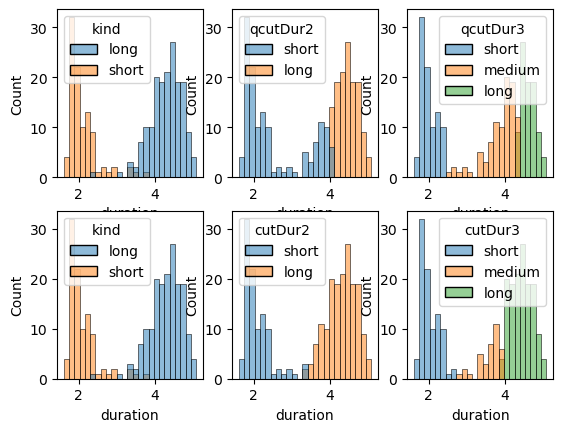

In [8]:
fig, ((hDur, qcDur2, qcDur3), (hDur2, cDur2, cDur3)) = plt.subplots(2, 3)
sns.histplot(data=geyser, x="duration", bins=25, hue="kind", ax=hDur)
sns.histplot(data=geyser, x="duration", bins=25, hue="qcutDur2", ax=qcDur2)
sns.histplot(data=geyser, x="duration", bins=25, hue="qcutDur3", ax=qcDur3)
sns.histplot(data=geyser, x="duration", bins=25, hue="kind", ax=hDur2)
sns.histplot(data=geyser, x="duration", bins=25, hue="cutDur2", ax=cDur2)
sns.histplot(data=geyser, x="duration", bins=25, hue="cutDur3", ax=cDur3)
plt.show()

### Implement custom binning borders

**Note** The standard list cut with scalers currrently requires top and bottom numbers, and the current implementation will define values outside of that range as NaN.

In [9]:
geyser["custCutDur2"] = pd.cut(geyser.duration, bins=[0, 3.3, 100], labels=["short", "long"])
geyser["custCutDur3"] = pd.cut(geyser.duration, bins=[0, 2.4, 4.0, 100], labels=["short", "medium", "long"])
geyser

,duration,waiting,kind,qcutDur2,qcutDur3,cutDur2,cutDur3,custCutDur2,custCutDur3
0,3.600,79,long,short,medium,long,medium,long,medium
1,1.800,54,short,short,short,short,short,short,short
2,3.333,74,long,short,medium,short,medium,long,medium
3,2.283,62,short,short,short,short,short,short,short
4,4.533,85,long,long,long,long,long,long,long
...,...,...,...,...,...,...,...,...,...
267,4.117,81,long,long,medium,long,long,long,long
268,2.150,46,short,short,short,short,short,short,short
269,4.417,90,long,long,long,long,long,long,long
270,1.817,46,short,short,short,short,short,short,short


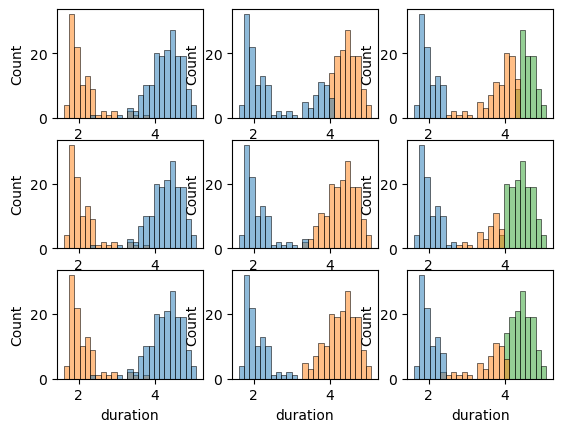

In [12]:
fig, ((hDur, qcDur2, qcDur3), (hDur2, cDur2, cDur3), (hDur3, custDur2, custDur3)) = plt.subplots(3, 3)
sns.histplot(data=geyser, x="duration", bins=25, hue="kind", ax=hDur, legend=None)
sns.histplot(data=geyser, x="duration", bins=25, hue="qcutDur2", ax=qcDur2, legend=None)
sns.histplot(data=geyser, x="duration", bins=25, hue="qcutDur3", ax=qcDur3, legend=None)
sns.histplot(data=geyser, x="duration", bins=25, hue="kind", ax=hDur2, legend=None)
sns.histplot(data=geyser, x="duration", bins=25, hue="cutDur2", ax=cDur2, legend=None)
sns.histplot(data=geyser, x="duration", bins=25, hue="cutDur3", ax=cDur3, legend=None)
sns.histplot(data=geyser, x="duration", bins=25, hue="kind", ax=hDur3, legend=None)
sns.histplot(data=geyser, x="duration", bins=25, hue="custCutDur2", ax=custDur2, legend=None)
sns.histplot(data=geyser, x="duration", bins=25, hue="custCutDur3", ax=custDur3, legend=None)
plt.show()